# Comparative Radar Chart — Interactive & LLM-Guided Clustering Systems

Visual comparison of **BlaBlaClust** against four related systems across six design dimensions.
See [related-work.md](related-work.md) for full discussion.

| Paper | System | Paradigm |
|---|---|---|
| Schild et al., EGC 2021 | Interactive Clustering | Pre-LLM, constraint-based |
| Zhang et al., EMNLP 2023 | ClusterLLM | LLM as relational oracle |
| Hong et al., EMNLP 2025 | Dial-In LLM | Fully automated LLM-ITL |
| Fischer & Biemann, arXiv 2026 | Perspectives | Visual HITL + fine-tuning |
| This work | BlaBlaClust | Conversational oracle |


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

In [8]:
# ── Scoring methodology ──────────────────────────────────────────────────────
# Each dimension is scored 1–5. Scores are qualitative assessments based on
# the design choices described in each paper, not directly comparable numbers
# (the systems are evaluated on different datasets and tasks).
#
# Automation        — how much the system operates without human input per turn
# Interactivity     — how tightly the human feedback loop is coupled to results
# Embedding adapt.  — how well the embedding space adapts to the specific task
# Domain generality — how broadly the system applies across domains/tasks
# Oracle access.    — how easy it is for a non-ML expert to act as oracle
# Eval. rigor       — strength of quantitative evaluation (ground truth, metrics)
#
# Note: Schild (2021) is pre-LLM and pre-neural; dashed fill distinguishes it.

dimensions = [
    "Automation",
    "Interactivity",
    "Embedding\nadaptability",
    "Domain\ngenerality",
    "Oracle\naccessibility",
    "Evaluation\nrigor",
]

systems = {
    "Interactive Clustering\n(Schild et al., 2021) [pre-LLM]": {
        "scores": [1, 4, 1, 3, 4, 3],
        "color": "#888888",
        "linestyle": (0, (3, 1, 1, 1)),  # densely dashdotted
    },
    "ClusterLLM\n(Zhang et al., 2023)": {
        "scores": [3, 1, 5, 5, 2, 5],
        "color": "#4a7c59",
        "linestyle": "--",
    },
    "Dial-In LLM\n(Hong et al., 2025)": {
        "scores": [5, 1, 3, 1, 1, 5],
        "color": "#c06b3e",
        "linestyle": "-.",
    },
    "Perspectives\n(Fischer & Biemann, 2026)": {
        "scores": [2, 5, 4, 4, 3, 3],
        "color": "#3e6fa3",
        "linestyle": ":",
    },
    "BlaBlaClust\n(this work)": {
        "scores": [2, 4, 2, 5, 5, 2],
        "color": "#8a3a6e",
        "linestyle": "-",
    },
}


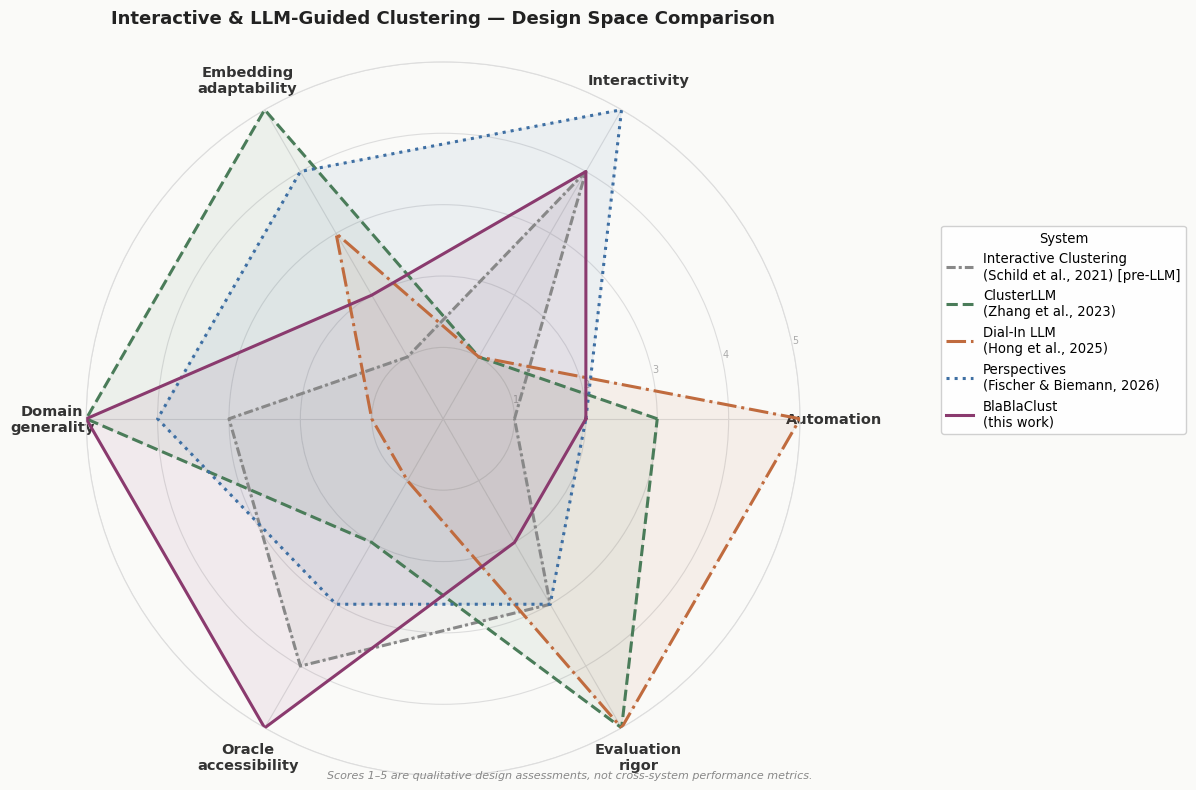

Saved: related-work-radar.png


In [9]:
N = len(dimensions)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("#fafaf8")
ax.set_facecolor("#fafaf8")

# ── Grid and spokes ──────────────────────────────────────────────────────────
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=7, color="#aaa")
ax.yaxis.set_tick_params(pad=2)
ax.set_rlabel_position(12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, fontsize=10.5, fontweight="bold", color="#333")
ax.tick_params(axis="x", pad=14)

ax.spines["polar"].set_color("#ddd")
ax.grid(color="#ddd", linewidth=0.8, linestyle="-")

# ── Plot each system ─────────────────────────────────────────────────────────
for name, cfg in systems.items():
    values = cfg["scores"] + cfg["scores"][:1]
    ax.plot(
        angles, values,
        linewidth=2.2,
        linestyle=cfg["linestyle"],
        color=cfg["color"],
        label=name,
        zorder=3,
    )
    ax.fill(angles, values, alpha=0.08, color=cfg["color"], zorder=2)

# ── Legend (right side, below title) ─────────────────────────────────────────
legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.55, 0.78),
    frameon=True,
    framealpha=0.9,
    edgecolor="#ccc",
    fontsize=9.5,
    title="System",
    title_fontsize=9.5,
)

# ── Title and scoring note ───────────────────────────────────────────────────
ax.set_title(
    "Interactive & LLM-Guided Clustering — Design Space Comparison",
    fontsize=13, fontweight="bold", color="#222",
    pad=28,
)
fig.text(
    0.5, 0.02,
    "Scores 1–5 are qualitative design assessments, not cross-system performance metrics.",
    ha="center", fontsize=8, color="#888", style="italic",
)

plt.tight_layout()
plt.savefig("related-work-radar.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved: related-work-radar.png")


## Scoring rationale

| Dimension | Schild (2021) | ClusterLLM | Dial-In LLM | Perspectives | BlaBlaClust |
|---|---|---|---|---|---|
| **Automation** | 1 — human annotates every pair manually | 3 — batch LLM queries, no human per-turn | 5 — fully automated post fine-tuning | 2 — human drives every refinement step | 2 — oracle required every turn |
| **Interactivity** | 4 — tight annotation loop per iteration | 1 — offline batch, no live loop | 1 — no interactive loop | 5 — live map manipulation | 4 — per-turn conversational dialogue |
| **Embedding adaptability** | 1 — pre-neural; TF-IDF/BoW, no adaptation | 5 — fine-tunes the embedder on LLM feedback | 3 — large capable model (BGE) but fixed | 4 — instruct-tuned + optional SetFit fine-tuning | 2 — MiniLM fixed; axis score appended as single dimension |
| **Domain generality** | 3 — banking domain tested; approach domain-agnostic in principle | 5 — evaluated on 14 diverse datasets | 1 — Chinese customer service only | 4 — DH corpora, various tasks | 5 — domain-agnostic by design |
| **Oracle accessibility** | 4 — binary similarity judgment only, no ML expertise; but many annotations needed | 2 — requires understanding triplet questions and providing few-shot demos | 1 — no human oracle | 3 — UI manipulation, visual but tool-dependent | 5 — free natural language, no ML expertise needed |
| **Evaluation rigor** | 3 — validated on banking dataset; cost analysis; no external NMI benchmark | 5 — NMI + ACC on 14 datasets with ground truth | 5 — NMI + downstream classifier ACC, ground truth | 3 — KNN accuracy proxy, no NMI | 2 — intrinsic metrics only (silhouette, coherence, compliance); no external ground truth |

> **Note on Schild (2021):** this system predates LLMs and transformer embeddings. It is included as the direct historical precursor of BlaBlaClust's interactive oracle paradigm. Scores reflect its classical constraint-based clustering design, not LLM capabilities.
